More SUPER Work, fixing isolation correlations

In [1]:
import numpy as np
import uproot
import math
import os, re, glob

In [2]:
##### Code to create different looseprimes

# ---- 1) Bit positions from egammaPIDdefs.h (
BIT = {
    "ClusterEtaRange_Photon":         0,   # (sometimes included in PhotonLoose)
    "ClusterHadronicLeakage_Photon": 10,   # Rhad
    "ClusterMiddleEnergy_Photon":    11,   # E277
    "ClusterMiddleEratio37_Photon":  12,   # Reta (common)
    "ClusterMiddleEratio33_Photon":  13,   # Rphi
    "ClusterMiddleWidth_Photon":     14,   # Weta2
    "ClusterStripsEratio_Photon":    15,   # f1 (called Eratio)
    "ClusterStripsDeltaEmax2_Photon":16,   # DeltaEmax2
    "ClusterStripsDeltaE_Photon":    17,   # DeltaE
    "ClusterStripsWtot_Photon":      18,   # Wstot
    "ClusterStripsDEmaxs1_Photon":   21,   # DEmaxs1
    "TrackMatchEoverP_Photon":       22,   # 
}

def mask_of(names):
    """Build a bit mask from a list of bit-name strings."""
    m = 0
    for name in names:
        m |= (1 << BIT[name])
    return m

# Base PhotonLoose mask (Run-2: Rhad, E277, Reta, Weta2, f1) ----
def photon_loose_mask():
    names = [
        "ClusterHadronicLeakage_Photon",  # 10 = Rhad
        "ClusterMiddleEnergy_Photon",     # 11 = E277
        "ClusterMiddleEratio37_Photon",   # 12 = Reta
        "ClusterMiddleWidth_Photon",      # 14 = Weta2
        "ClusterStripsEratio_Photon",     # 15 = f1 (called eratio)
        "ClusterMiddleEratio33_Photon"    # 13 = Rphi
    ]
    
    return mask_of(names)

# ---- 3) LoosePrime variants __
def build_looseprime_masks():
    PL = photon_loose_mask()

    # Convenience aliases
    DEmx2      = "ClusterStripsDeltaEmax2_Photon"
    DeltaE     = "ClusterStripsDeltaE_Photon"
    Wstot      = "ClusterStripsWtot_Photon"
    DEmaxs1    = "ClusterStripsDEmaxs1_Photon"

    masks = {}

    # LoosePrime2: PhotonLoose + {DeltaEmax2, DeltaE, DEmaxs1, Wstot}
    masks["LoosePrime2"] = PL | mask_of([DEmx2, DeltaE, DEmaxs1, Wstot])

    # LoosePrime3: PhotonLoose + {DeltaEmax2, DEmaxs1, Wstot}
    masks["LoosePrime3"] = PL | mask_of([DEmx2, DEmaxs1 , Wstot])

    # LoosePrime4: PhotonLoose + {DeltaEmax2, Wstot}
    masks["LoosePrime4"] = PL | mask_of([DEmx2, Wstot])

    # LoosePrime4a: PhotonLoose + {DeltaEmax2, DEmaxs1}
    masks["LoosePrime4a"] = PL | mask_of([DEmx2, DEmaxs1])

    # LoosePrime5: PhotonLoose + {DeltaEmax2}
    masks["LoosePrime5"] = PL | mask_of([DEmx2])

    masks["Run1"]=0x45fc01

    return masks

# Check to see if photon passes specific mask
def passes(mask, isEM):
    """Return boolean array: True if photon passes the 'LoosePrimeX' mask."""
    return (isEM & mask) == 0


In [3]:
# --- MC branches you need (matches your earlier single-file code) ---
BRANCHES = [
    "ph_pt", "ph_eta",
    "ph_topoetcone20", "ph_topoetcone40", "ph_ptcone20",
    "ph_select_tightID", "ph_isEM",
    "ph_select_hybridCOIso",            # your chosen ISO flag
    "ph_truthprompt", "ph_truthEFP",    # MC truth labels
    "weight_total",                     # MC event weight
    # event-level preselection fields (per-photon length in these ntuples)
    "met_met", "jet_cleanTightBad_prod", "j1_pt",
    "mindPhiJetMet", "nBTagJets", "nElectrons", "nMuons"
]

def load_arrays(file_path: str):
    """
    MC-only: read required branches from 'picontuple'.
    Raises a clear error if anything is missing.
    """
    with uproot.open(file_path) as f:
        tree = f["picontuple"]
        have = set(tree.keys())
        missing = [b for b in BRANCHES if b not in have]
        if missing:
            raise KeyError(
                f"Missing branches in {os.path.basename(file_path)}: {missing}"
            )
        arr = tree.arrays(BRANCHES, library="np")
    return arr


def prepare_globals_for_file(arr):
    """
    Prepare all the physics variables used by abcd_counts_mc().

    Returns a dict with:
      pt, eta, topo20, topo40, ptc20, hybridIso, tight, prompt, isEM, w, TOT_mask
    """
    # photon-level kinematics & IDs
    pt     = arr["ph_pt"].astype(float)
    eta    = arr["ph_eta"].astype(float)
    topo20 = arr["ph_topoetcone20"].astype(float)
    topo40 = arr["ph_topoetcone40"].astype(float)
    ptc20  = arr["ph_ptcone20"].astype(float)

    hybridIso = (arr["ph_select_hybridCOIso"] == 1)
    tight     = (arr["ph_select_tightID"] == 1)
    isEM      = arr["ph_isEM"].astype(np.uint32)

    # MC truth + weight
    prompt = (arr["ph_truthprompt"] == 1)
    if "ph_truthEFP" in arr:
        prompt = prompt | (arr["ph_truthEFP"] == 1)
    w = arr["weight_total"].astype(float)

    # event-level fields (stored per-photon length in these ntuples)
    met_met           = arr["met_met"].astype(float)
    jet_cleanTightBad = arr["jet_cleanTightBad_prod"].astype(np.int32)
    j1_pt             = arr["j1_pt"].astype(float)
    mindPhiJetMet     = arr["mindPhiJetMet"].astype(float)
    nBTagJets         = arr["nBTagJets"].astype(np.int32)
    nElectrons        = arr["nElectrons"].astype(np.int32)
    nMuons            = arr["nMuons"].astype(np.int32)

    abs_eta = np.abs(eta)
    eta_ok  = (abs_eta < 2.37) & ~((abs_eta > 1.37) & (abs_eta < 1.52))
    pt_ok   = (pt > 10_000.0)

    evt_ok = (
        (met_met > 200_000.0) &
        (jet_cleanTightBad == 1) &
        (j1_pt > 150_000.0) &
        (mindPhiJetMet > 0.4) &
        (nBTagJets == 0) &
        (nElectrons == 0) &
        (nMuons == 0)
    )

    TOT_mask = eta_ok & pt_ok & evt_ok

    # Return everything as a dictionary
    return {
        "pt": pt,
        "eta": eta,
        "topo20": topo20,
        "topo40": topo40,
        "ptc20": ptc20,
        "hybridIso": hybridIso,
        "tight": tight,
        "prompt": prompt,
        "isEM": isEM,
        "w": w,
        "TOT_mask": TOT_mask,
    }

In [4]:
# ── ISO masks ────────────────────────────────────────────────────────────────
def iso_mask_fixedcutloose(pt, topo20, ptc20):
    return (topo20 < 0.065 * pt) & ((ptc20 / pt) < 0.05)

def iso_mask_fixedcuttight(pt, topo40, ptc20):
    return (topo40 < (0.022 * pt + 2.45)) & ((ptc20 / pt) < 0.05)

def iso_mask_tightcaloonly(pt, topo40):
    return (topo40 < (0.022 * pt + 2.45))

# ── Weighted errors for derived quantities (uses weighted σ inputs) ──────────
def abcd_errors(
    A, B, C, D,
    sA, sB, sC, sD,
    C_fake,
    C_true_fakes=None,
    sTrueFakes=None,
):
    # σ(C_fake) = |C_fake| * sqrt( (σA/A)^2 + (σB/B)^2 + (σD/D)^2 )
    if all(np.isfinite(x) and x != 0 for x in (A, B, D)) and np.isfinite(C_fake):
        sCfake = abs(C_fake) * math.sqrt(
            (sA / abs(A))**2 + (sB / abs(B))**2 + (sD / abs(D))**2
        )
    else:
        sCfake = float("nan")

    # Purity = 1 - C_fake/C ; σ^2 = (σ_Cfake/C)^2 + (C_fake*σ_C/C^2)^2
    if np.isfinite(C_fake) and C != 0:
        purity  = 1.0 - (C_fake / C)
        sPurity = math.sqrt(
            (sCfake / abs(C))**2 + ((C_fake * sC) / (abs(C)**2))**2
        ) if np.isfinite(sCfake) else float("nan")
    else:
        purity, sPurity = float("nan"), float("nan")

    # Ratio of fakes = C_fake / C_true_fakes (aka fake_validation)
    if (C_true_fakes is not None) and np.isfinite(C_fake) and C_fake != 0 and C_true_fakes != 0:
        r = C_fake / C_true_fakes
        print(f"C_fake/C_true_fakes: {C_fake}/{C_true_fakes}")
        if sTrueFakes is None:
            # Prefer passing sTrueFakes (weighted σ); this fallback is for unweighted.
            sTrueFakes = math.sqrt(abs(C_true_fakes))
        sRatioFakes = abs(r) * math.sqrt(
            (sCfake / abs(C_fake))**2 + (sTrueFakes / abs(C_true_fakes))**2
        ) if np.isfinite(sCfake) and np.isfinite(sTrueFakes) else float("nan")
    else:
        r, sRatioFakes = float("nan"), float("nan")


    # R prime calculations
    if all(v not in (0.0, np.inf, -np.inf) and np.isfinite(v) for v in (A, B, C, D)):
        Rprime = (A * D) / (C_true_fakes * B)
        sRprime = abs(Rprime) * math.sqrt(
            (sA / abs(A))**2 + (sD / abs(D))**2 + (sTrueFakes / abs(C_true_fakes))**2 + (sB / abs(B))**2
        )
    else:
        Rprime, sRprime = float("nan"), float("nan")

    return dict(
        sA=sA, sB=sB, sC=sC, sD=sD,
        sCfake=sCfake,
        purity=purity, sPurity=sPurity,
        ratio_fakes=r, sRatioFakes=sRatioFakes,
        fake_validation=r, sFakeValidation=sRatioFakes,
        sTrueFakes=sTrueFakes,
        Rprime=Rprime, sRprime=sRprime,   
    )

#prevent negative yields
def safe_weighted_sum(mask, w):
    """Returns (sum_w, sqrt(sum_w2)), setting negatives to 0."""
    w_sum = float(np.sum(w * mask))
    w_sum2 = float(np.sum((w**2) * mask))
    if w_sum < 0:
        w_sum = 0.0
    return w_sum, math.sqrt(w_sum2)

# ── ABCD (weighted) ──────────────────────────────────────────────────────────
def abcd_counts(iso, looseMask, tight, prompt, TOT_mask, w):
    """
    iso: boolean array (True = isolated)
    looseMask: global photon "looseprime" selection (boolean)
    """
    # include BOTH total baseline and loose selection
    global_mask = TOT_mask & looseMask

    # Region masks
    mA = global_mask &  tight & ~iso & ~prompt
    mB = global_mask & ~tight & ~iso & ~prompt
    mC = global_mask &  tight &  iso
    mD = global_mask & ~tight &  iso & ~prompt

    # Weighted yields (sum w) and weighted sigmas (sqrt sum w^2)
    A, sA = safe_weighted_sum(mA, w)
    B, sB = safe_weighted_sum(mB, w)
    C, sC = safe_weighted_sum(mC, w)
    D, sD = safe_weighted_sum(mD, w)

    # ABCD prediction
    C_fake = (A * D / B) if B != 0 else float("nan")

    # Truth fakes in C (weighted) and its weighted sigma
    mC_true_fake = mC & ~prompt
    C_true_fakes  = float(np.sum(w * mC_true_fake))
    sTrueFakes    = math.sqrt(float(np.sum((w**2) * mC_true_fake)))

    # Purities
    purity = 1 - (C_fake / C) if (C > 0 and np.isfinite(C_fake)) else np.nan
    # truth "real" purity (weighted)
    C_real_weighted = float(np.sum(w * (mC & prompt)))
    realPurity = (C_real_weighted / C) if C != 0 else np.nan

    errs = abcd_errors(
        A, B, C, D,
        sA, sB, sC, sD,
        C_fake,
        C_true_fakes=C_true_fakes,
        sTrueFakes=sTrueFakes,
    )

    # return everything pretty_print expects
    return A, B, C, D, C_fake, purity, realPurity, C_true_fakes, errs

def pretty_print(name, A, B, C, D, C_fake, purity, realPurity, totalFakes, errs):
    print(f"\n=== {name} ===")
    print(f"A (tight & !Iso; bg-only): {A:.3f}  ± {errs['sA']:.3f}")
    print(f"B (!tight & !Iso; bg-only): {B:.3f}  ± {errs['sB']:.3f}")
    print(f"C (tight &  Iso; total)  : {C:.3f}  ± {errs['sC']:.3f}")
    print(f"D (!tight &  Iso; bg-only): {D:.3f}  ± {errs['sD']:.3f}")
    print('---')
    if np.isfinite(C_fake):
        if np.isfinite(errs['sCfake']):
            print(f"C_fake (pred) = {C_fake:.3f} ± {errs['sCfake']:.3f}")
        else:
            print(f"C_fake (pred) = {C_fake:.3f} (σ undefined)")
    else:
        print("C_fake (pred) = NaN (B=0)")
    # weighted truth fakes with weighted σ
    if np.isfinite(totalFakes):
        sTrue = errs.get('sTrueFakes', float('nan'))
        if np.isfinite(sTrue):
            print(f"True fakes in C (weighted) = {totalFakes:.3f} ± {sTrue:.3f}")
        else:
            print(f"True fakes in C (weighted) = {totalFakes:.3f}")
    # ratio of fakes (pred/true)
    if np.isfinite(errs['ratio_fakes']):
        if np.isfinite(errs['sRatioFakes']):
            print(f"Ratio of Fakes (pred/true) = {errs['ratio_fakes']:.3f} ± {errs['sRatioFakes']:.3f}")
        else:
            print(f"Ratio of Fakes (pred/true) = {errs['ratio_fakes']:.3f} (σ undefined)")
    # purity
    if np.isfinite(errs['purity']):
        print(f"Purity (C_real / C) = {errs['purity']:.4f} ± {errs['sPurity']:.4f}")
    else:
        print("Purity (C_real / C) = NaN")
    # truth purity (weighted)
    print(f"Actual purity from truth = {realPurity:.4f}" if np.isfinite(realPurity) else "Actual purity from truth = NaN")

    # R prime
    if np.isfinite(errs.get('Rprime', np.nan)):
        if np.isfinite(errs.get('sRprime', np.nan)):
            print(f"R' = (A·D)/(C·B) = {errs['Rprime']:.4f} ± {errs['sRprime']:.4f}")
        else:
            print(f"R' = (A·D)/(C·B) = {errs['Rprime']:.4f} (σ undefined)")
    else:
        print("R' = NaN (one or more regions are zero)")
    
    print()

HOW TO: Run one singular file given the prepare_globals_for_file function

In [5]:
FILE = "/data/mhance/SUSY/ntuples/v3.Y/output_Wtaunu_L_CVetoBVeto_mc20.root"

# Load arrays and build per-photon variables
arr  = load_arrays(FILE)              # returns dict/array of branches (per photon)
vars = prepare_globals_for_file(arr)  # returns dict with pt, topo20, topo40, ptc20,
                                      # tight, prompt, isEM, w, TOT_mask, etc.

# LoosePrime (per-photon) — this is the one you want to pass
fc_mask = ((vars["isEM"] & np.uint32(0x45fc01)) == 0)

# Choose ISO; for the ATLAS WPs use your helpers with per-photon inputs
for name, iso_fun in [
    ("FixedCutLoose",  lambda: iso_mask_fixedcutloose(vars["pt"], vars["topo20"], vars["ptc20"])),
    ("FixedCutTight",  lambda: iso_mask_fixedcuttight(vars["pt"], vars["topo40"], vars["ptc20"])),
    ("TightCaloOnly",  lambda: iso_mask_tightcaloonly(vars["pt"], vars["topo40"])),
]:
    iso = iso_fun()   # boolean array, same length as pt/… (per photon)

    # --- sanity checks (optional, very helpful) ---
    for key, a in {
        "iso": iso, "fc_mask": fc_mask, "tight": vars["tight"],
        "prompt": vars["prompt"], "TOT_mask": vars["TOT_mask"], "w": vars["w"],
    }.items():
        assert a.shape == vars["pt"].shape, f"{key} shape {a.shape} != pt {vars['pt'].shape}"

    results = abcd_counts(
        iso,                # isolated?
        fc_mask,            # LoosePrime mask (per-photon)
        vars["tight"],      # Tight ID (per-photon)
        vars["prompt"],     # truth-prompt (per-photon)
        vars["TOT_mask"],   # baseline selection (per-photon)
        vars["w"],          # weights (per-photon)
    )

    pretty_print(name, *results)


C_fake/C_true_fakes: 113.72864014698087/139.89141861902567

=== FixedCutLoose ===
A (tight & !Iso; bg-only): 317.346  ± 16.627
B (!tight & !Iso; bg-only): 322.755  ± 18.801
C (tight &  Iso; total)  : 784.954  ± 19.968
D (!tight &  Iso; bg-only): 115.667  ± 8.147
---
C_fake (pred) = 113.729 ± 11.982
True fakes in C (weighted) = 139.891 ± 8.703
Ratio of Fakes (pred/true) = 0.813 ± 0.099
Purity (C_real / C) = 0.8551 ± 0.0157
Actual purity from truth = 0.8218
R' = (A·D)/(C·B) = 0.8130 ± 0.0995

C_fake/C_true_fakes: 54.05742303481358/79.12063822282425

=== FixedCutTight ===
A (tight & !Iso; bg-only): 378.116  ± 17.560
B (!tight & !Iso; bg-only): 383.583  ± 19.643
C (tight &  Iso; total)  : 486.810  ± 15.923
D (!tight &  Iso; bg-only): 54.839  ± 5.830
---
C_fake (pred) = 54.057 ± 6.855
True fakes in C (weighted) = 79.121 ± 6.622
Ratio of Fakes (pred/true) = 0.683 ± 0.104
Purity (C_real / C) = 0.8890 ± 0.0145
Actual purity from truth = 0.8375
R' = (A·D)/(C·B) = 0.6832 ± 0.1038

C_fake/C_true_

In [6]:
FILE = "/data/mhance/SUSY/ntuples/v3.1/output_Wtaunu_L_CVetoBVeto_mc20.root"

arr = load_arrays(FILE)        
vars = prepare_globals_for_file(arr) 
masks = build_looseprime_masks()

hybridIso = (arr["ph_select_hybridCOIso"] == 1)

LP4_BITS = masks["LoosePrime4"]


lp_pass = passes(LP4_BITS, vars["isEM"])
results = abcd_counts(
        hybridIso,                # isolated?
        fc_mask,            # LoosePrime mask (per-photon)
        vars["tight"],      # Tight ID (per-photon)
        vars["prompt"],     # truth-prompt (per-photon)
        vars["TOT_mask"],   # baseline selection (per-photon)
        vars["w"],          # weights (per-photon)
    )

pretty_print(f"LoosePrime4 | HybridCaloIso", *results)


C_fake/C_true_fakes: 90.37834764115942/117.46770016707842

=== LoosePrime4 | HybridCaloIso ===
A (tight & !Iso; bg-only): 169.088  ± 11.683
B (!tight & !Iso; bg-only): 467.931  ± 20.824
C (tight &  Iso; total)  : 538.481  ± 17.051
D (!tight &  Iso; bg-only): 250.112  ± 12.787
---
C_fake (pred) = 90.378 ± 8.748
True fakes in C (weighted) = 117.468 ± 8.939
Ratio of Fakes (pred/true) = 0.769 ± 0.095
Purity (C_real / C) = 0.8322 ± 0.0171
Actual purity from truth = 0.7819
R' = (A·D)/(C·B) = 0.7694 ± 0.0947



In [7]:
import os, re, glob, math
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Find base mc20 / mc23 files
# -----------------------------
BASE_DIR = "/data/mhance/SUSY/ntuples/v3.Y"

def list_base_files(period_suffix="20"):
    exclude = ["gammajet", "jetjet", "jj", "N2"] #Excluding files that are mainly signal
    pat = re.compile(fr"_mc{period_suffix}\.root$")
    all_files = glob.glob(os.path.join(BASE_DIR, "*.root"))
    
    files = [
        p for p in all_files
        if pat.search(os.path.basename(p))
        and not any(ex in p for ex in exclude)
    ]
    
    return sorted(files)

def list_data_files():
    """
    Return all real data ROOT files matching output_data_*.root
    (covers Run-2 and Run-3 data years)
    """
    pat = re.compile(r"output_data_20(15|16|17|18|22|23)\.root$")
    files = [p for p in glob.glob(os.path.join(BASE_DIR, "*.root")) if pat.search(os.path.basename(p))]
    return sorted(files)

run2_files = list_base_files("20")
run3_files = list_base_files("23")
data_files = list_data_files()
print(f"Run-2 base files: {len(run2_files)}   Run-3 base files: {len(run3_files)}")
print(f"Data files: {len(data_files)}")

# ---------------------------------------
# 2) Choose LoosePrime working point (LP4)
# ---------------------------------------
LP_BITS = build_looseprime_masks()["LoosePrime4"]   # your mask builder

# ----------------------------------------------------
# 3) Process a set of files and collect (R, sR) values
# ----------------------------------------------------
def process_files(file_list, label):
    """
    Uses only the 'hybrid' isolation: ph_select_hybridCOIso == 1.
    Returns:
      results: dict with key 'hybridIso' -> list of (R, sR)
      means  : dict with key 'hybridIso' -> (Rbar, sRbar, N_used)
    """
    results = {"hybridIso": [], "Rprime": []}  # add a bucket for R′

    for path in file_list:
        tag = os.path.basename(path)
        try:
            arr = load_arrays(path)        
            vars = prepare_globals_for_file(arr) 
            lp_pass = passes(LP_BITS, vars["isEM"])
            hybridIso = (arr["ph_select_hybridCOIso"] == 1)

            A,B,C,D,C_fake,purity,realPurity,totalFakes,errs = abcd_counts(hybridIso, lp_pass, vars["tight"], vars["prompt"], vars["TOT_mask"], vars["w"])

            # --- existing R (fake-validation) ---
            R  = errs.get("fake_validation", np.nan)
            sR = errs.get("sFakeValidation", np.nan)
            if np.isfinite(R) and np.isfinite(sR) and sR > 0:
                results["hybridIso"].append((R, sR))

            # --- NEW: store R′ and its uncertainty ---
            Rp  = errs.get("Rprime",  np.nan)
            sRp = errs.get("sRprime", np.nan)


            if ( Rp < 0.05) :
                print(f"{path} : {Rp}")
            
            if np.isfinite(Rp) and np.isfinite(sRp):
                results["Rprime"].append((Rp, sRp))

        except Exception as e:
            print(f"[{label}] [SKIP FILE] {tag}: {e}")
            continue

    # Inverse-variance mean over files
    means = {}
    pairs = results["hybridIso"]
    if len(pairs) == 0:
        means["hybridIso"] = (np.nan, np.nan, 0)
    else:
        num = sum(R/(sR*sR) for R, sR in pairs)
        den = sum(1.0/(sR*sR) for _, sR in pairs)
        Rbar  = num/den if den > 0 else np.nan
        sRbar = 1.0/math.sqrt(den) if den > 0 else np.nan
        means["hybridIso"] = (Rbar, sRbar, len(pairs))

    return results, means

# ---- run it
res20, mean20 = process_files(run2_files, "mc20")
res23, mean23 = process_files(run3_files, "mc23")

# (Optional) quick printout of the means
R20, s20, N20 = mean20["hybridIso"]
R23, s23, N23 = mean23["hybridIso"]
print(f"Run-2 hybridIso: mean fake_validation = {R20:.3f} ± {s20:.3f}  (N={N20})")
print(f"Run-3 hybridIso: mean fake_validation = {R23:.3f} ± {s23:.3f}  (N={N23})")


Run-2 base files: 71   Run-3 base files: 58
Data files: 6
C_fake/C_true_fakes: 0.3297135236646433/0.8000043592910515
C_fake/C_true_fakes: 3.583946259295546/5.3895837750751525
C_fake/C_true_fakes: 9.609290709131361/12.366762694437057
C_fake/C_true_fakes: 9.336863911991811/14.022241357713938
C_fake/C_true_fakes: 14.234464448906811/13.750307929411065
C_fake/C_true_fakes: 0.24007824251049717/0.48583222180604935
C_fake/C_true_fakes: 0.31847525349840666/0.5924718677997589
C_fake/C_true_fakes: 33.934939724711725/40.485027318140226
C_fake/C_true_fakes: 0.361178856112131/0.5057909278402235
C_fake/C_true_fakes: 9.725648778282125/10.636291510992464
C_fake/C_true_fakes: 0.7567836740902144/0.9703050758534317
C_fake/C_true_fakes: 22.11101284345289/25.70104953949226
C_fake/C_true_fakes: 0.1356386745544894/0.011679715738864616
C_fake/C_true_fakes: 0.3566308453439583/0.31394269607699243
C_fake/C_true_fakes: 0.24910374646113004/0.21002931835027994
C_fake/C_true_fakes: 0.8771872498399119/1.06657305956005

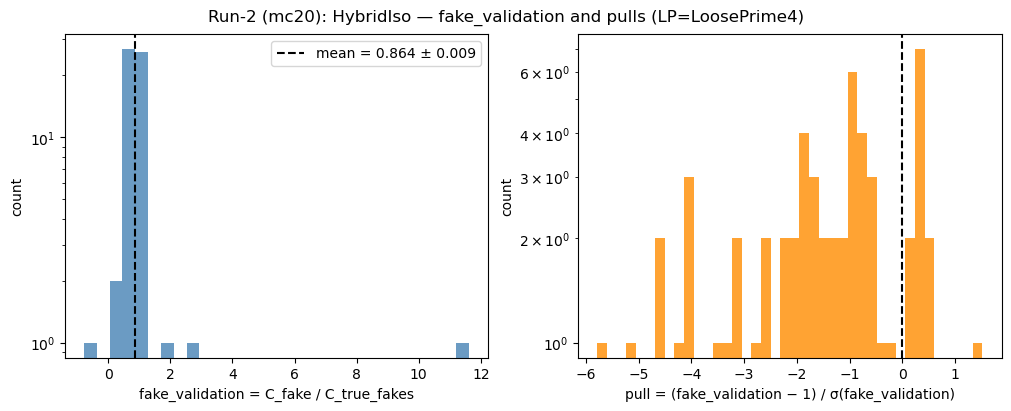

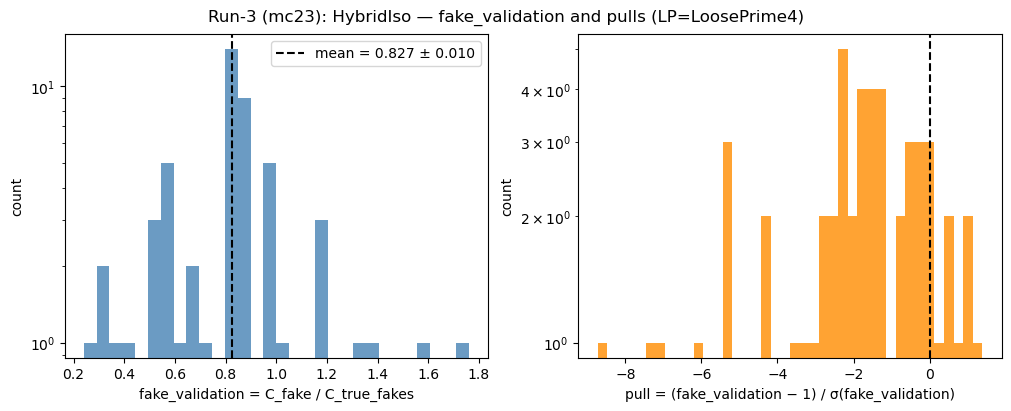

In [8]:

# ------------------------------------------------
# 5) Histograms (Run-2 and Run-3 shown separately)
# ------------------------------------------------
def arrays_from_pairs(pairs):
    if len(pairs)==0:
        return np.array([]), np.array([])
    R = np.array([x[0] for x in pairs], dtype=float)
    s = np.array([x[1] for x in pairs], dtype=float)
    return R, s

def plot_period(label, results, means):
    R, s = arrays_from_pairs(results["hybridIso"])
    Z = (R - 1.0)/s
    Rbar, sRbar, _ = means["hybridIso"]

    fig, axes = plt.subplots(1, 2, figsize=(10,4), constrained_layout=True)
    fig.suptitle(f"{label}: HybridIso — fake_validation and pulls (LP=LoosePrime4)")

    # Left: fake_validation
    ax = axes[0]
    ax.set_yscale('log')
    ax.hist(R, bins=30, alpha=0.8, color='steelblue')
    ax.axvline(Rbar, color='black', linestyle='--', label=f"mean = {Rbar:.3f} ± {sRbar:.3f}")
    ax.set_xlabel("fake_validation = C_fake / C_true_fakes")
    ax.set_ylabel("count")
    ax.legend()

    # Right: pulls
    ax = axes[1]
    ax.set_yscale('log')
    ax.hist(Z, bins=40, alpha=0.8, color='darkorange')
    ax.axvline(0.0, color='black', linestyle='--')
    ax.set_xlabel("pull = (fake_validation − 1) / σ(fake_validation)")
    ax.set_ylabel("count")

    plt.show()
    
# Generate separate figures for each run period
plot_period("Run-2 (mc20)", res20, mean20)
plot_period("Run-3 (mc23)", res23, mean23)

Found 135 base Run-2 files


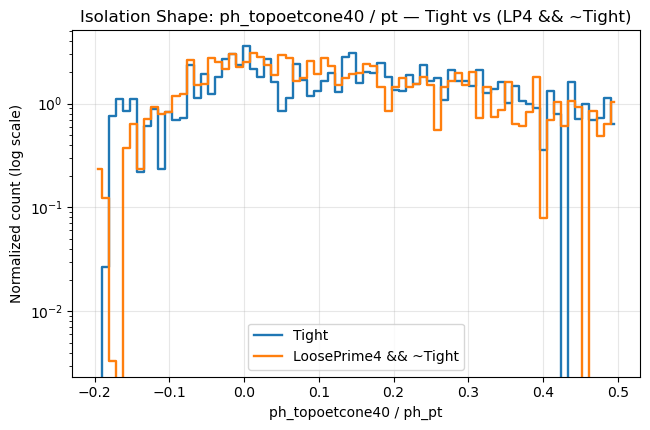

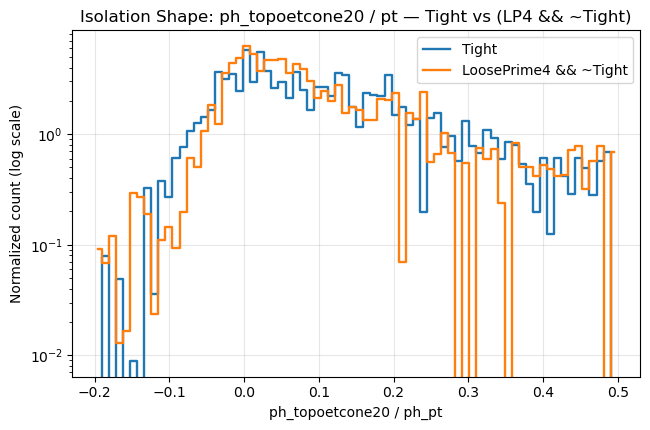

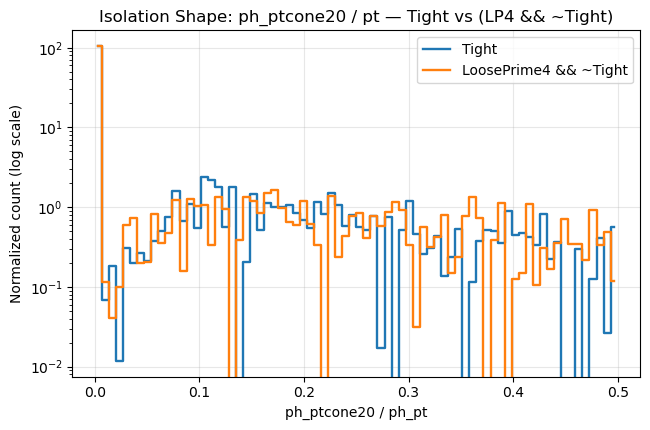

In [9]:
import os, re, glob
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Find base mc20 files only
# -----------------------------
BASE_DIR = "/data/mhance/SUSY/ntuples/v3.Y"

def list_base_mc20():
    pat = re.compile(r"_mc20\.root$")
    files = [p for p in glob.glob(os.path.join(BASE_DIR, "*.root"))
             if pat.search(os.path.basename(p))]
    return sorted(files)

run2_files = list_base_mc20()
print(f"Found {len(run2_files)} base Run-2 files")

# ---------------------------------------
# 2) LoosePrime working point (LP4 bits)
# ---------------------------------------
LP4_BITS = build_looseprime_masks()["LoosePrime4"]

# -----------------------------
# 3) Binning (tweak if you want)
# -----------------------------
# calorimeter iso can be (slightly) negative due to pileup / noise subtraction
bins_calo = np.linspace(-0.20, 0.50, 75)  # for topoetcone20/40 / pt
bins_trk  = np.linspace( 0.00, 0.50, 75)  # for ptcone20 / pt

def hist_accumulator(bins):
    """Return zeroed hist arrays for tight and lp4&~tight."""
    nb = len(bins) - 1
    return {
        "tight":       np.zeros(nb, dtype=float),
        "lp4_notight": np.zeros(nb, dtype=float),
        "sumw_tight":       0.0,   # for possible re-normalization checks
        "sumw_lp4_notight": 0.0,
    }

H_topo40 = hist_accumulator(bins_calo)
H_topo20 = hist_accumulator(bins_calo)
H_ptc20  = hist_accumulator(bins_trk)

# -----------------------------
# 4) Loop files and accumulate
# -----------------------------
for path in run2_files:
    try:
        arr = load_arrays(FILE)        
        prepare_globals_for_file(arr)     
        lp_pass = passes(LP4_BITS, vars["isEM"])   # boolean per-photon pass of LP4
    except Exception as e:
        print(f"[ISO PLOT | SKIP] {os.path.basename(path)}: {e}")
        continue

    # selections
    sel_tight       = vars["TOT_mask"] & lp_pass &  vars["tight"] & ~vars["prompt"]
    sel_lp4_notight = vars["TOT_mask"] & lp_pass & ~vars["tight"]

    # variables (ratios)
    x40  = vars["topo40"] / vars["pt"]
    x20  = vars["topo20"] / vars["pt"]
    xpt  = vars["ptc20"]  / vars["pt"]

    w = vars["w"]

    # --- Tight
    if np.any(sel_tight):
        H_topo40["tight"] += np.histogram(x40[sel_tight], bins=bins_calo, weights=w[sel_tight])[0]
        H_topo20["tight"] += np.histogram(x20[sel_tight], bins=bins_calo, weights=w[sel_tight])[0]
        H_ptc20["tight"]  += np.histogram(xpt[sel_tight],  bins=bins_trk,  weights=w[sel_tight])[0]
        H_topo40["sumw_tight"] += float(np.sum(w[sel_tight]))
        H_topo20["sumw_tight"] += float(np.sum(w[sel_tight]))
        H_ptc20["sumw_tight"]  += float(np.sum(w[sel_tight]))

    # --- LP4 && ~Tight
    if np.any(sel_lp4_notight):
        H_topo40["lp4_notight"] += np.histogram(x40[sel_lp4_notight], bins=bins_calo, weights=w[sel_lp4_notight])[0]
        H_topo20["lp4_notight"] += np.histogram(x20[sel_lp4_notight], bins=bins_calo, weights=w[sel_lp4_notight])[0]
        H_ptc20["lp4_notight"]  += np.histogram(xpt[sel_lp4_notight],  bins=bins_trk,  weights=w[sel_lp4_notight])[0]
        H_topo40["sumw_lp4_notight"] += float(np.sum(w[sel_lp4_notight]))
        H_topo20["sumw_lp4_notight"] += float(np.sum(w[sel_lp4_notight]))
        H_ptc20["sumw_lp4_notight"]  += float(np.sum(w[sel_lp4_notight]))

# -----------------------------
# 5) Normalize each to unit area
# -----------------------------
def normalize_to_area1(h, bins):
    bw = np.diff(bins)
    # convert to density-like shape: divide by (total area) so integral = 1
    total = np.sum(h * bw)
    return (h / total) if total > 0 else h

def centers(bins):
    return 0.5 * (bins[:-1] + bins[1:])

def plot_one(title, bins, H):
    c = centers(bins)
    t1 = normalize_to_area1(H["tight"],       bins)
    t2 = normalize_to_area1(H["lp4_notight"], bins)

    plt.figure(figsize=(6.6, 4.4))
    plt.step(c, t1, where="mid", label="Tight",                 linewidth=1.7)
    plt.step(c, t2, where="mid", label="LoosePrime4 && ~Tight", linewidth=1.7)
    plt.yscale("log")
    plt.xlabel(f"{title} / ph_pt")
    plt.ylabel("Normalized count (log scale)")
    plt.title(f"Isolation Shape: {title} / pt — Tight vs (LP4 && ~Tight)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# -----------------------------
# 6) Make the three plots
# -----------------------------
plot_one("ph_topoetcone40", bins_calo, H_topo40)
plot_one("ph_topoetcone20", bins_calo, H_topo20)
plot_one("ph_ptcone20",     bins_trk,  H_ptc20)


Run 2 (mc20): Best-fit flat R′ = 0.8639 ± 0.0093


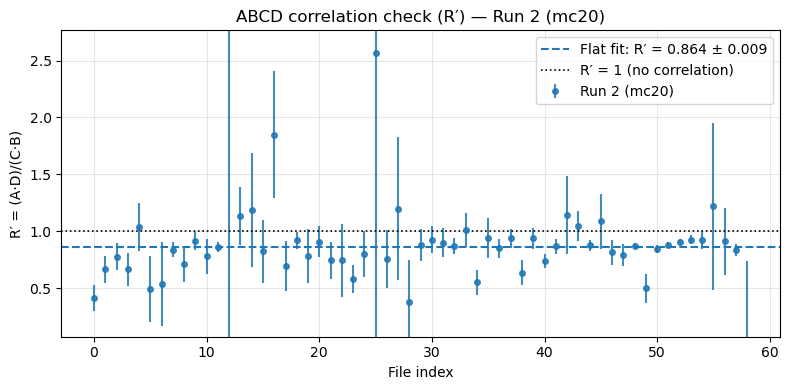

Run 3 (mc23): Best-fit flat R′ = 0.8272 ± 0.0096


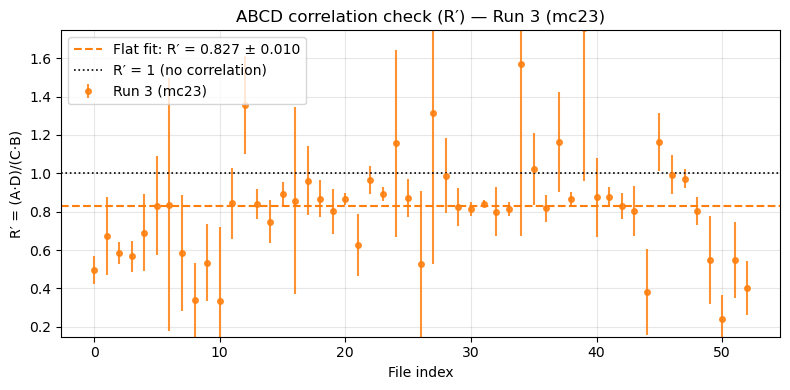

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Helpers ----------
def _vals_errs(res_dict, key="hybridIso"):
    """
    Returns (values, errors) arrays from results dict.
    key='hybridIso' -> (R, sR) fake-validation ratios (default)
    key='Rprime'    -> (R', sR') correlation ratios
    """
    pairs = np.array(res_dict.get(key, []), dtype=float)
    if pairs.size == 0:
        return np.array([]), np.array([])
    return pairs[:, 0], pairs[:, 1]

def _auto_ylim(values, frac_pad=0.15):
    """
    Pick a nice y-range from the central 2–98% of the data, with padding.
    Falls back to (0,2) if it's empty.
    """
    vals = values[np.isfinite(values)]
    if vals.size == 0:
        return (0.0, 2.0)
    lo, hi = np.percentile(vals, [2, 98])
    pad = frac_pad * (hi - lo + 1e-9)
    return (lo - pad, hi + pad)

# ---------- Core plotting function for ONE run ----------
def plot_single_run_Rprime(res_dict, run_label="Run 2 (mc20)", color="tab:blue"):
    """
    Make a scatter+errorbar plot of R' = (A·D)/(C·B) for one campaign.
    res_dict should be the output 'results' from process_files(...) for that campaign.
    """
    R, sR = _vals_errs(res_dict, key="Rprime")
    n = R.size
    x = np.arange(n)

    plt.figure(figsize=(8,4))

    if n:
        plt.errorbar(
            x, R, yerr=sR,
            fmt='o', ms=4,
            color=color, alpha=0.85,
            label=run_label
        )

        # ----- Add flat best-fit line (weighted mean) -----
        weights = np.where(sR > 0, 1.0 / (sR ** 2), 1.0)  # avoid division by zero
        R_best = np.sum(weights * R) / np.sum(weights)
        R_best_err = np.sqrt(1.0 / np.sum(weights))

        plt.axhline(R_best, color=color, ls='--', lw=1.5,
                    label=f"Flat fit: R′ = {R_best:.3f} ± {R_best_err:.3f}")

        print(f"{run_label}: Best-fit flat R′ = {R_best:.4f} ± {R_best_err:.4f}")

    # reference line R'=1 (perfect ABCD independence)
    plt.axhline(1.0, color='k', ls=':', lw=1.2, label="R′ = 1 (no correlation)")

    # smart y-limits
    ymin, ymax = _auto_ylim(R)
    plt.ylim(ymin, ymax)

    plt.xlabel("File index")
    plt.ylabel("R′ = (A·D)/(C·B)")
    plt.title(f"ABCD correlation check (R′) — {run_label}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ---------- call it for each run ----------
plot_single_run_Rprime(res20, run_label="Run 2 (mc20)", color="tab:blue")
plot_single_run_Rprime(res23, run_label="Run 3 (mc23)", color="tab:orange")
